In [1]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
from tensorflow.keras.datasets import mnist

In [3]:
(x_train, y_train), (x_test, y_test) =mnist.load_data()

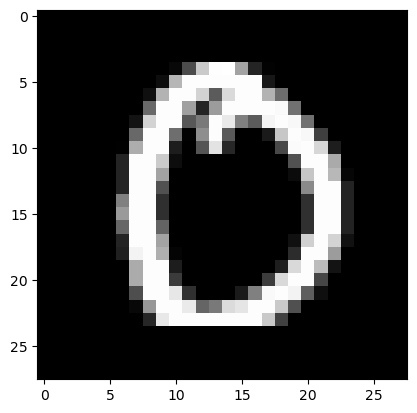

In [4]:
import matplotlib.pyplot as plt
img=x_train[88]
plt.imshow(img,cmap="gray")

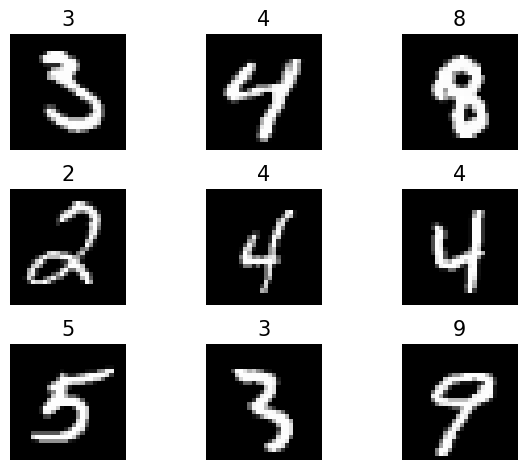

In [5]:
import random
for i in range(9):
    plt.subplot(3,3,i+1)
    num=random.randint(0,len(x_train))
    plt.imshow(x_train[num],cmap="gray")
    plt.title(y_train[num],fontsize=15)
    plt.axis("off")
plt.tight_layout()

In [6]:
x_train=x_train.reshape(60000,784)
x_test=x_test.reshape(10000,784)

In [7]:
x_train=x_train/ 255

In [8]:
x_test=x_test/255



In [9]:
from tensorflow.keras.utils import to_categorical
num_categories=10
y_train=to_categorical(y_train,num_categories)
y_test=to_categorical(y_test,num_categories)

In [10]:
from tensorflow.keras.models import Sequential
model=Sequential()


In [11]:
from tensorflow.keras.layers import Dense 
model.add(Dense(512,activation="relu",input_shape=(784,)))
model.add(Dense(512,activation="relu"))
model.add(Dense(10,activation="softmax"))

C:\Users\LJENG\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 669,706 (2.55 MB)

 Trainable params: 669,706 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(loss='categorical_crossentropy',metrics=["accuracy"])

In [ ]:
history=model.fit(x_train,y_train,epochs=5,verbose=2,validation_data=(x_test,y_test))

Epoch 1/5
1875/1875 - 13s - 7ms/step - accuracy: 0.9434 - loss: 0.1889 - val_accuracy: 0.9714 - val_loss: 0.0957
Epoch 2/5
1875/1875 - 13s - 7ms/step - accuracy: 0.9757 - loss: 0.0836 - val_accuracy: 0.9740 - val_loss: 0.1026
Epoch 3/5


In [ ]:
history=model.fit(x_train,y_train,epochs=5,verbose=2,validation_data=(x_test,y_test))

# 1/2/26


In [1]:
import pandas as pd
test_df=pd.read_csv("sign_mnist_valid.csv")
train_df=pd.read_csv("sign_mnist_train.csv")
train_df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,pixel40,pixel41,pixel42,pixel43,pixel44,pixel45,pixel46,pixel47,pixel48,pixel49,pixel50,pixel51,pixel52,pixel53,pixel54,pixel55,pixel56,pixel57,pixel58,pixel59,...,pixel725,pixel726,pixel727,pixel728,pixel729,pixel730,pixel731,pixel732,pixel733,pixel734,pixel735,pixel736,pixel737,pixel738,pixel739,pixel740,pixel741,pixel742,pixel743,pixel744,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,156,158,160,163,165,159,166,168,170,170,171,171,171,172,171,171,170,170,169,111,121,129,135,141,144,148,151,154,157,160,163,164,170,119,152,171,171,170,171,172,172,172,172,172,171,171,170,113,123,131,...,202,202,201,200,142,151,160,165,188,190,187,150,119,109,85,79,79,78,137,203,205,206,206,207,207,206,206,204,205,204,203,202,142,151,160,172,196,188,188,190,135,96,86,77,77,79,176,205,207,207,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,157,158,156,154,154,153,152,151,149,149,148,147,146,144,142,143,138,92,108,158,159,159,159,160,160,160,160,160,160,160,159,158,157,155,154,153,152,151,150,149,149,147,147,146,142,116,143,161,161,161,...,87,91,101,94,153,139,115,89,77,72,65,77,106,137,174,185,146,121,111,112,100,78,120,157,168,107,99,121,133,97,95,120,135,116,95,79,69,86,139,173,200,185,175,198,124,118,94,140,133,84,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,186,185,185,185,184,184,184,181,181,179,179,179,178,178,109,52,66,77,83,188,189,189,188,188,189,188,188,188,188,187,185,185,187,182,177,182,182,182,180,180,179,180,135,67,73,73,71,190,190,190,...,195,195,193,192,202,179,152,140,118,85,75,78,82,77,75,87,142,203,208,205,203,204,203,201,200,200,199,198,196,195,194,193,198,166,132,114,89,74,79,77,74,78,132,188,210,209,206,205,204,203,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,211,209,207,208,207,206,203,202,201,200,198,197,195,192,197,171,51,52,54,212,213,215,215,212,212,213,212,212,211,211,209,208,209,206,204,203,202,201,200,199,197,193,204,149,44,49,46,215,217,218,...,222,220,219,217,63,56,52,52,59,56,17,16,20,17,17,14,120,217,237,244,247,242,233,231,230,229,227,225,223,221,220,216,58,51,49,50,57,60,17,15,18,17,19,1,159,255,237,239,237,236,235,234,233,231,230,226,225,222,229,163
4,12,164,167,170,172,176,179,180,184,185,186,188,189,189,190,191,189,190,190,187,190,192,193,191,191,192,192,194,194,166,169,172,174,177,180,182,185,186,187,190,191,190,191,192,192,194,182,152,146,189,195,194,193,193,194,195,195,167,170,173,...,208,209,211,211,99,101,100,100,100,97,163,200,179,161,150,138,138,151,132,97,90,77,88,117,123,127,129,134,145,152,156,179,105,106,105,104,104,104,175,199,178,152,136,130,136,150,118,92,85,76,92,105,105,108,133,163,157,163,164,179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27450,12,189,189,190,190,192,193,193,193,193,194,193,193,194,194,195,195,196,194,195,196,196,197,196,197,197,196,195,195,189,190,192,192,193,194,195,196,196,196,193,194,1

In [2]:
y_train=train_df['label']
y_test=test_df['label']
del train_df['label']
del test_df['label']


In [3]:
y_train.shape,y_test.shape

((27455,), (7172,))

In [4]:
x_train=train_df.values
x_test=test_df.values

In [5]:
x_train.shape,x_test.shape

((27455, 784), (7172, 784))

In [6]:
x_train=x_train/255
x_test=x_test/255

In [8]:
from tensorflow.keras.utils import to_categorical
y_train=to_categorical(y_train,24)
y_test=to_categorical(y_test,24)

In [9]:
x_train=x_train.reshape(-1,28,28,1)
x_test=x_test.reshape(-1,28,28,1)

In [10]:
x_train.shape,x_test.shape

((27455, 28, 28, 1), (7172, 28, 28, 1))